# Day 02 - Missing Values

Yesterday we found that two columns have missing values:
- MonthlyIncome (~20% missing)
- NumberOfDependents (~2.6% missing)

Today we will:
- Visualize the missing values properly
- Understand WHY they might be missing
- Decide how to fill them
- Fill them and check our work

## Step 1 - Import and load

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('cs-training.csv', index_col=0)

# Always keep a backup before making changes
df_backup = df.copy()

In [4]:
df.shape

(150000, 11)

## Step 2 - Visualize missing values with missingno

missingno is a library just for visualizing missing data
Install it first if you haven't: pip install missingno

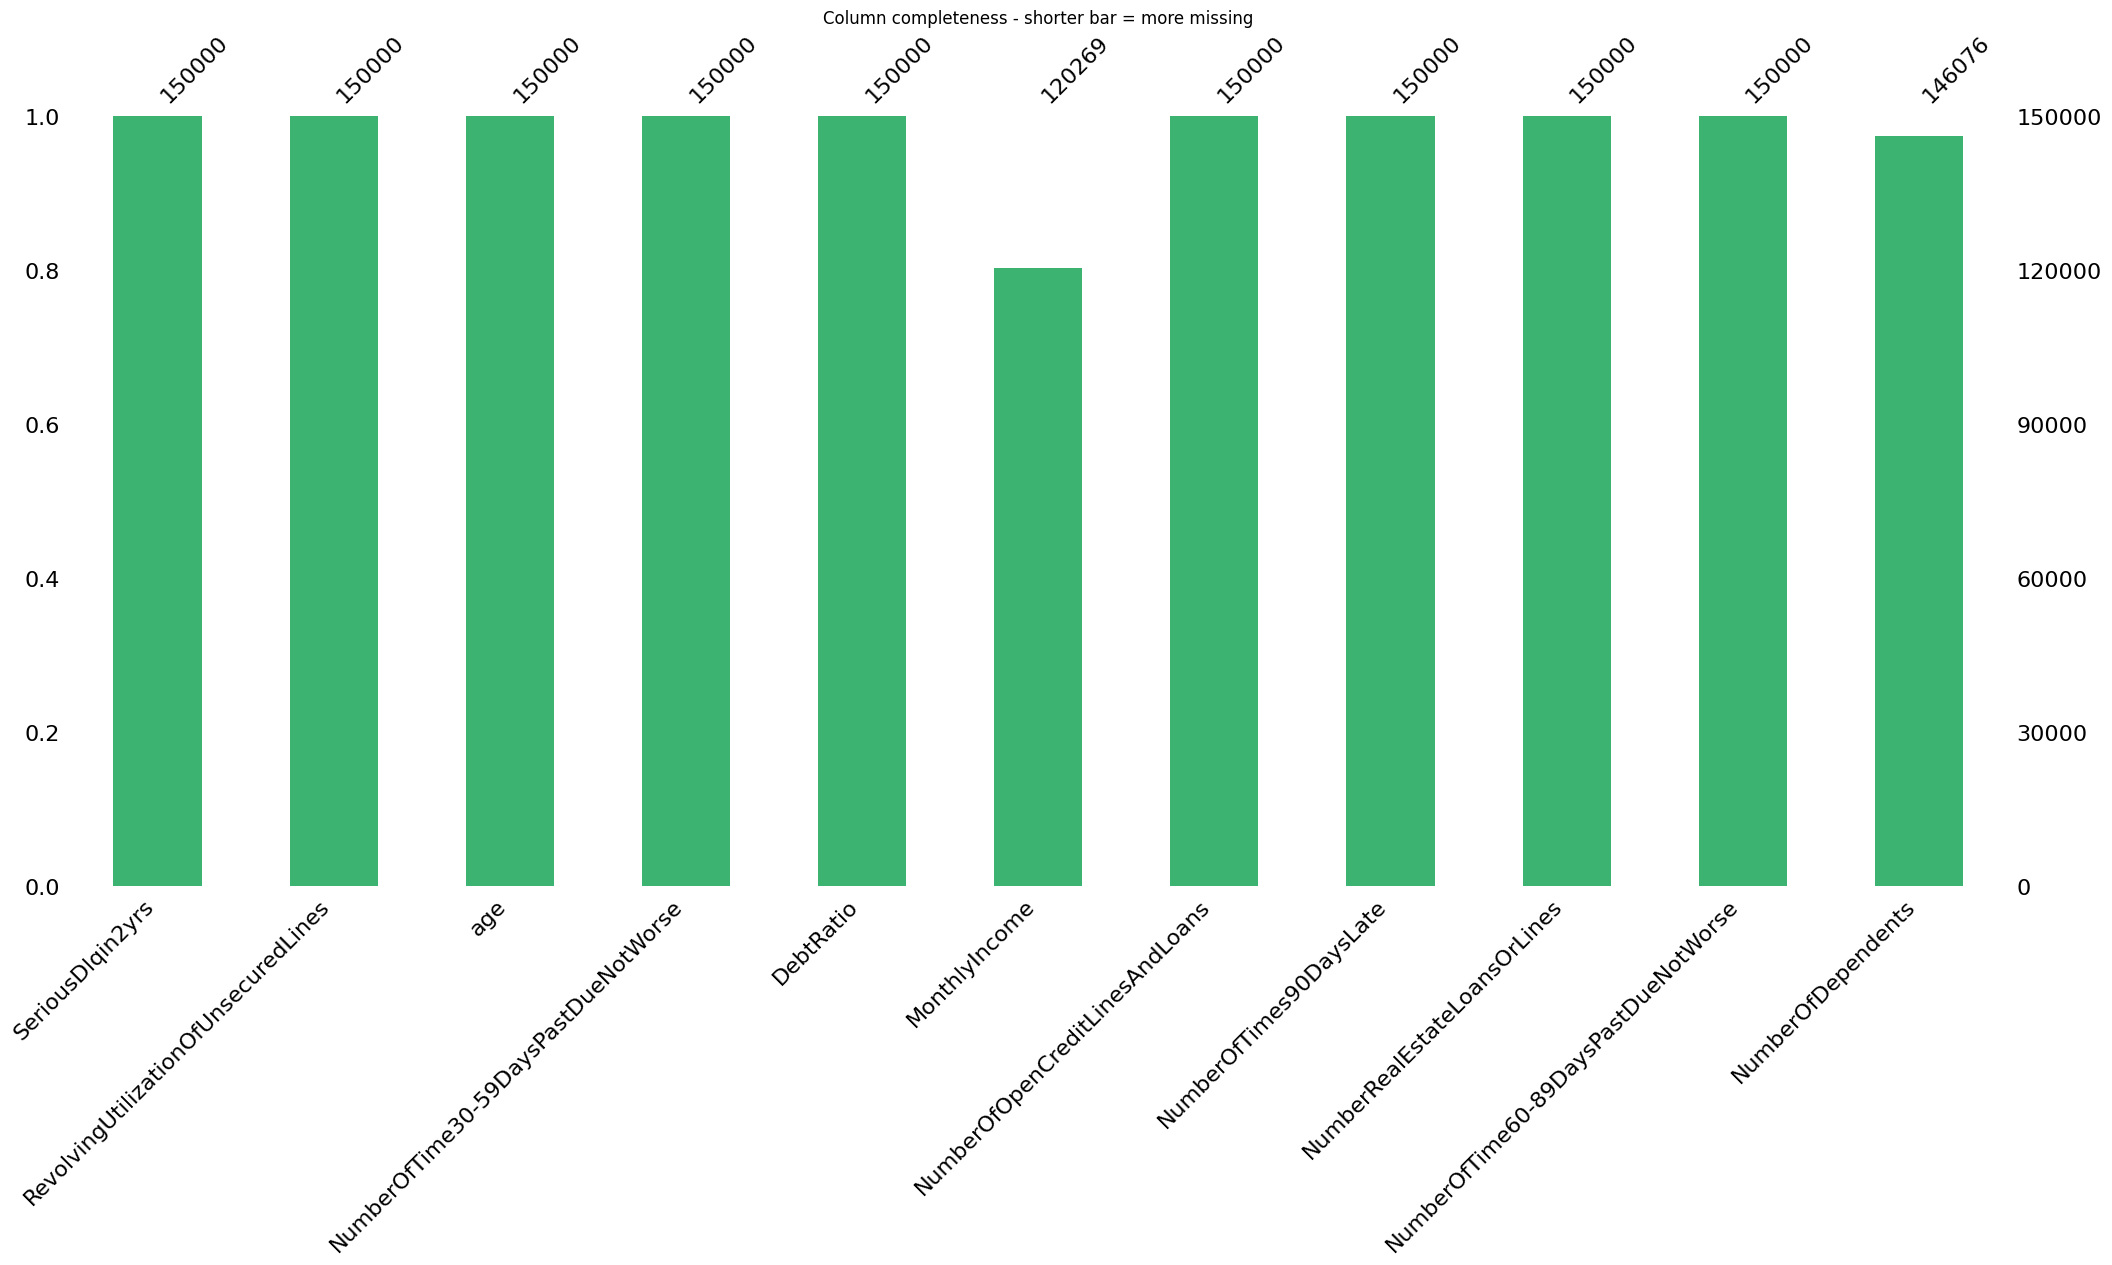

In [5]:
# Bar chart - how complete is each column?
msno.bar(df , color = 'mediumseagreen')
plt.title('Column completeness - shorter bar = more missing')
plt.show()

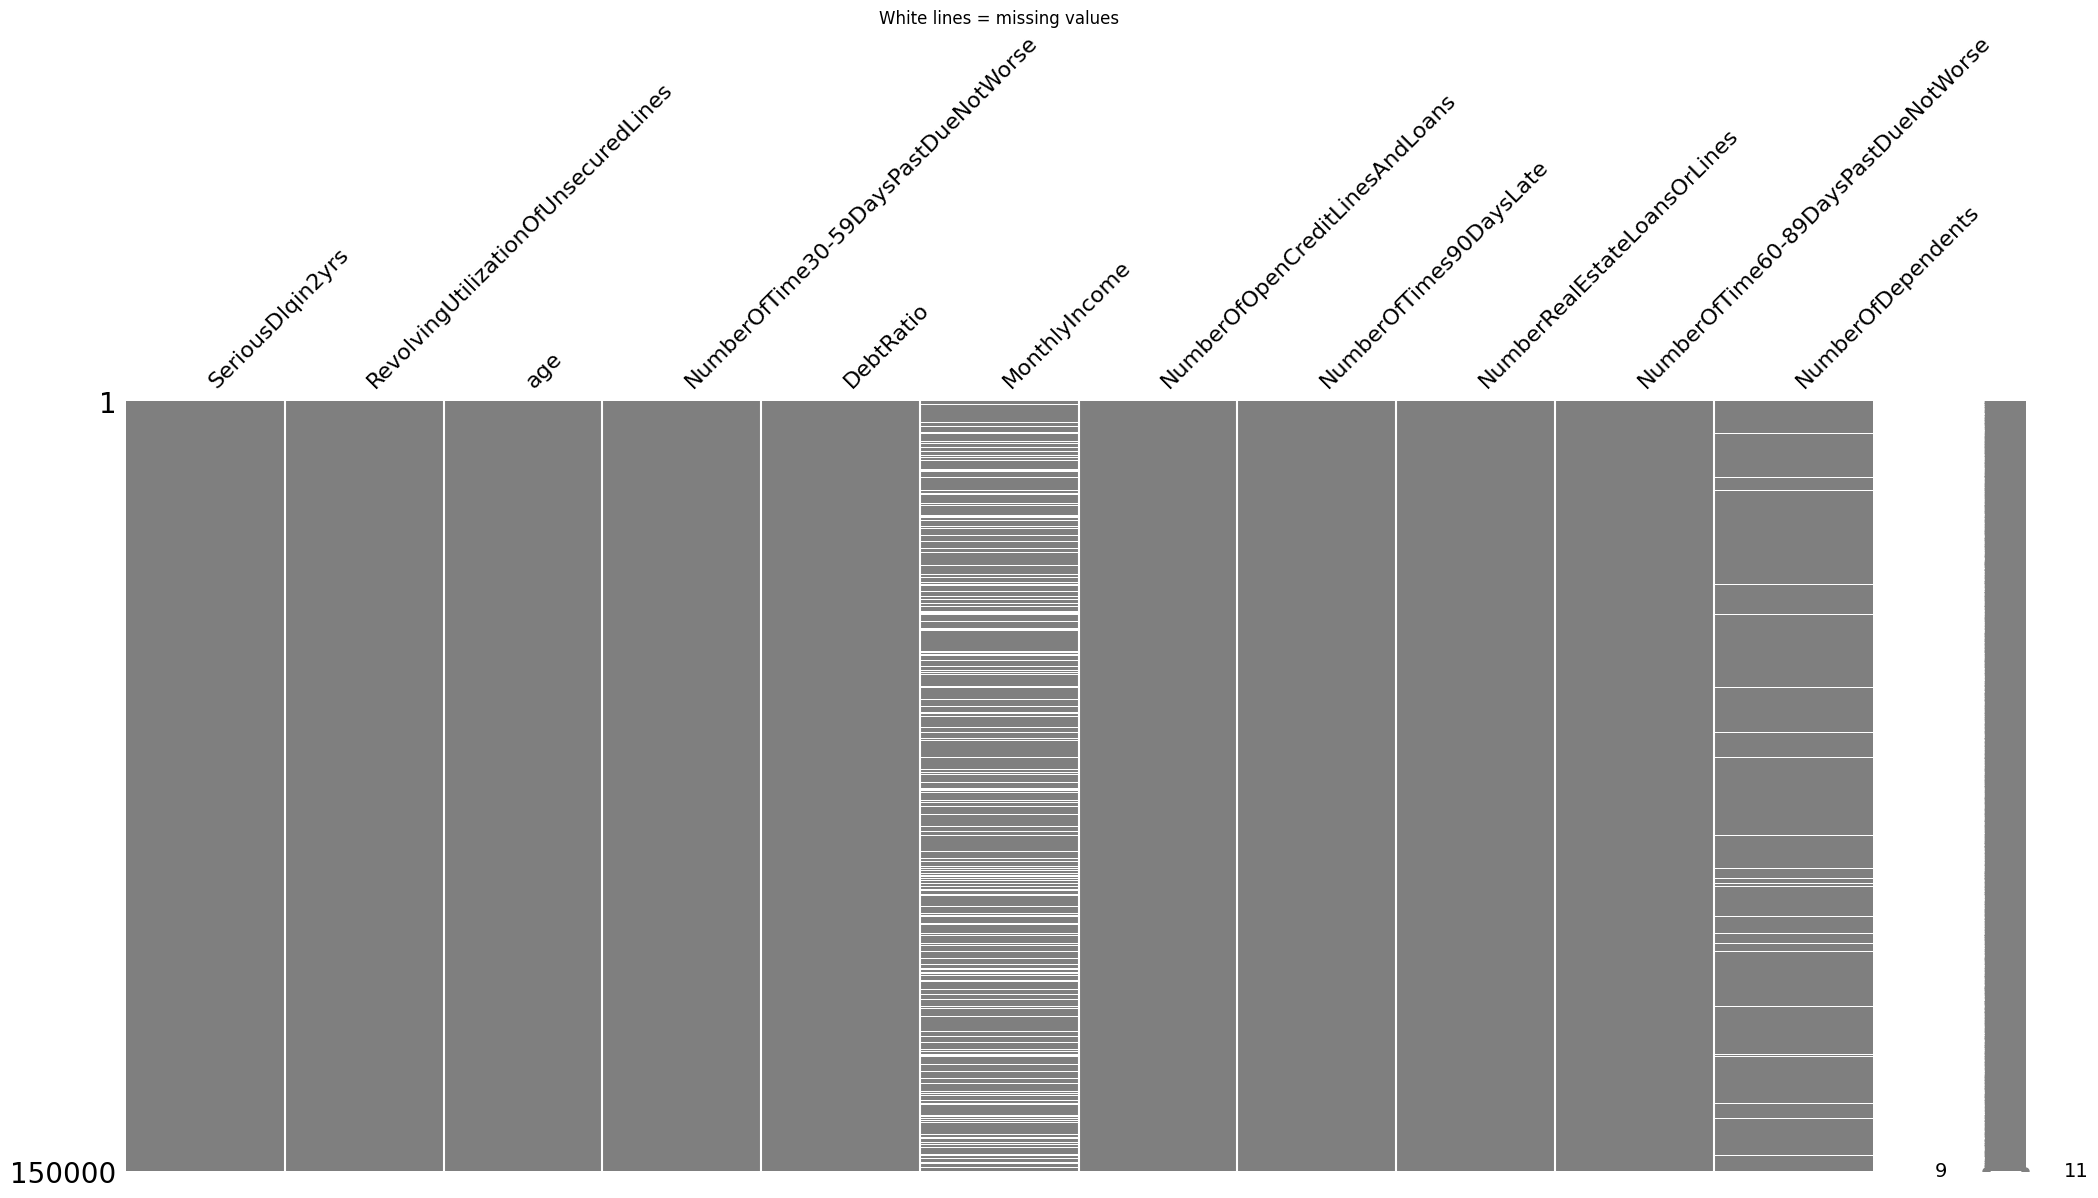

In [6]:
# Matrix - white lines are missing values
# If white lines in two columns align = they go missing together
msno.matrix(df , color = (0.5 , 0.5 , 0.5))
plt.title('White lines = missing values')
plt.show()

## Step 3 - Does missing income relate to default?

This is a very important question.
If people who hide their income are riskier, then missing income IS useful information.
We need to save that information before we fill in the missing values.

In [7]:
# Create a simple column: 1 if income is missing, 0 if not
df['income_is_missing'] = df['MonthlyIncome'].isnull().astype(int)

<Axes: xlabel='income_is_missing'>

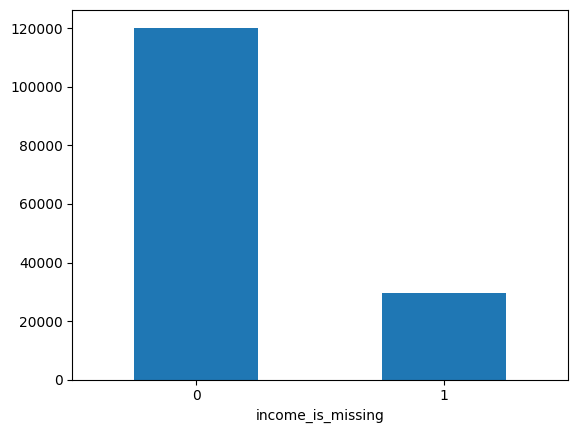

In [23]:
# Check how many have missing income
df['income_is_missing'].value_counts().plot(kind = 'bar' , rot = 0)

In [24]:
# Compare default rate: income provided vs income missing
(
    df_backup.groupby('income_is_missing')['SeriousDlqin2yrs']
      .agg(['count', 'sum', 'mean'])
)

KeyError: 'income_is_missing'

Is the default rate higher when income is missing?

If YES - we keep the income_is_missing column because it tells the model something useful
If NO - we can just fill and forget

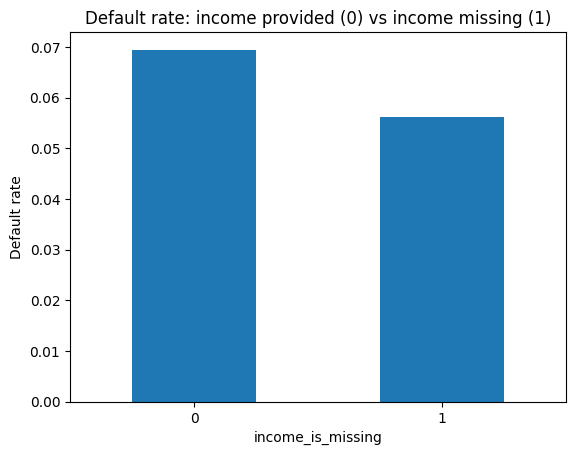

In [10]:
# Plot it to see clearly
df.groupby('income_is_missing')['SeriousDlqin2yrs'].mean().plot(kind='bar')
plt.title('Default rate: income provided (0) vs income missing (1)')
plt.ylabel('Default rate')
plt.xticks(rotation=0)
plt.show()

## Step 4 - Now fill the missing values

For MonthlyIncome: use median (not mean - because income data is skewed)
For NumberOfDependents: fill with 0 (missing probably means no dependents)

In [11]:
# Check income before filling
print('Missing income before:', df['MonthlyIncome'].isnull().sum())

Missing income before: 29731


In [12]:
# What is the median income?
df['MonthlyIncome'].median()

5400.0

In [13]:
# Fill missing income with median
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

In [14]:
# Check - should be 0 now
print('Missing income after:', df['MonthlyIncome'].isnull().sum())

Missing income after: 0


In [15]:
df['NumberOfDependents'].mode()

0    0.0
Name: NumberOfDependents, dtype: float64

In [16]:
# Fill dependents with Mode - 0
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [17]:
# Check all missing values now
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
income_is_missing                       0
dtype: int64

## Step 5 - Compare income before and after filling

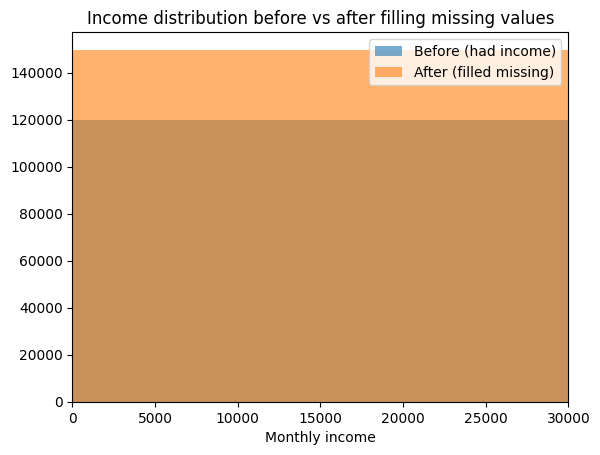

In [18]:
# Before - only rows that had income
plt.hist(df_backup['MonthlyIncome'].dropna(), bins=50, alpha=0.6, label='Before (had income)')

# After - all rows including filled ones
plt.hist(df['MonthlyIncome'], bins=50, alpha=0.6, label='After (filled missing)')

plt.xlim(0, 30000)  # zoom in to see clearly
plt.title('Income distribution before vs after filling missing values')
plt.xlabel('Monthly income')
plt.legend()
plt.show()

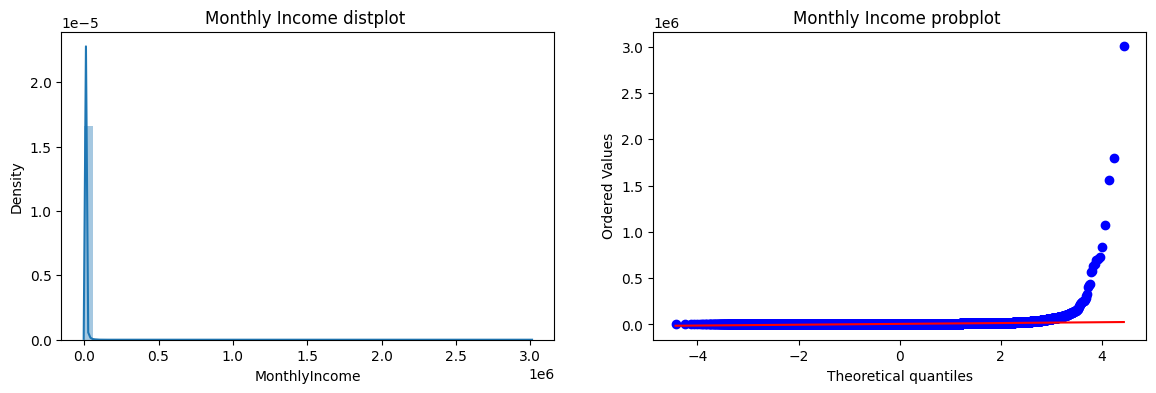

In [19]:
import scipy.stats as stats
fig , (ax1 , ax2) = plt.subplots(ncols =  2 , figsize = (14,4))

sns.distplot(df['MonthlyIncome'] ,ax = ax1, kde = True )
ax1.set_title(f'Monthly Income distplot ')

stats.probplot(df['MonthlyIncome'] , dist = 'norm' , plot =ax2)
ax2.set_title(f'Monthly Income probplot ')

plt.show()

## Step 6 - Save the cleaned data

In [20]:
df.to_csv('cs-training-day2-cleaned.csv')
print('Saved!')
print('Shape:', df.shape)

Saved!
Shape: (150000, 12)


## My observations today (fill this yourself)

1. Is the default rate higher when income is missing? Yes
2. Why did I use median instead of mean to fill income : Because mean is effeted by Outlier.
3. Why did I fill dependents with 0 instead of median : Since its a binary column or you can say categorical , so here replaced with mode value is good descision
4. What does the income_is_missing column tell the model : It tells the model whether the original income value was missing before imputation.

---
Tomorrow - Day 03: We will find and handle outliers